In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/ecommerce_churn.csv")

In [ ]:
# Create a working copy

df = df.copy()

print("Dataset shape:", df.shape)

Dataset shape: (5630, 20)


## Baisc dataset exploration

In [ ]:
# Display last 5 rows

df.tail()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169


In [ ]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [ ]:
df.sample(5, random_state=42)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4331,54332,1,1.0,Computer,3,7.0,COD,Female,4.0,6,Mobile Phone,5,Single,2,0,22.0,2.0,2.0,1.0,148
1988,51989,0,15.0,Mobile Phone,1,9.0,Debit Card,Female,3.0,1,Laptop & Accessory,1,Married,3,1,13.0,1.0,1.0,3.0,152
3443,53444,0,13.0,Computer,1,29.0,Credit Card,Female,3.0,4,Fashion,5,Single,3,1,14.0,2.0,NaN,9.0,234
4559,54560,0,5.0,Phone,1,7.0,Debit Card,Male,4.0,5,Mobile Phone,5,Married,3,0,13.0,4.0,4.0,3.0,147
4898,54899,0,13.0,Mobile Phone,1,7.0,Debit Card,Female,4.0,5,Grocery,1,Married,3,0,17.0,10.0,NaN,9.0,252


In [ ]:
# Dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5630
Number of columns: 20


In [ ]:
# Column names

print("Columns:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns:

1. CustomerID
2. Churn
3. Tenure
4. PreferredLoginDevice
5. CityTier
6. WarehouseToHome
7. PreferredPaymentMode
8. Gender
9. HourSpendOnApp
10. NumberOfDeviceRegistered
11. PreferedOrderCat
12. SatisfactionScore
13. MaritalStatus
14. NumberOfAddress
15. Complain
16. OrderAmountHikeFromlastYear
17. CouponUsed
18. OrderCount
19. DaySinceLastOrder
20. CashbackAmount


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259
CustomerID,0,0.000000
PreferredLoginDevice,0,0.000000
Churn,0,0.000000


Several behavioural and order-related features contain missing values, with DaySinceLastOrder having the highest number of missing observations. Instead of removing these records immediately, I will first investigate whether the missing values are associated with customer churn.

In [ ]:
# Count empty strings in each column

empty_strings = (df == "").sum()

empty_strings[empty_strings > 0]

,0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Target variable

In [ ]:
print(df["Churn"].value_counts())

Churn
0    4682
1     948
Name: count, dtype: int64


In [ ]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


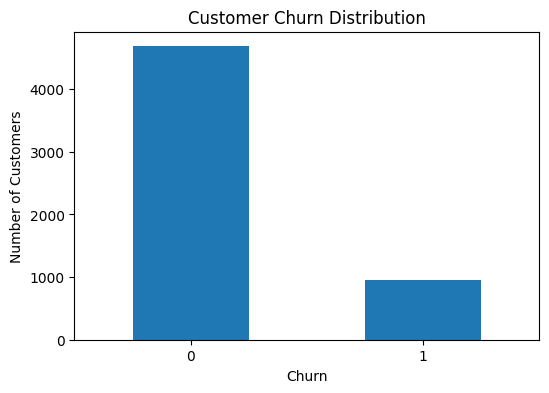

In [ ]:
df["Churn"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.0,0.00,1.0
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.0,16.00,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.0,3.00,3.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.0,20.00,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.0,3.00,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.0,4.00,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.0,4.00,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.0,6.00,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.0,1.00,1.0


In [ ]:
for col in categorical_cols:
    print("-------------------------------")
    print(df[col].value_counts(dropna=False))

-------------------------------
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
-------------------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
-------------------------------
Gender
Male      3384
Female    2246
Name: count, dtype: int64
-------------------------------
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
-------------------------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [ ]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']

PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender
['Female' 'Male']

PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus
['Single' 'Divorced' 'Married']


In [ ]:
for col in numeric_cols:
    print(
        f"{col}: "
        f"min={df[col].min()}, "
        f"max={df[col].max()}, "
        f"median={df[col].median()}"
    )

CustomerID: min=50001, max=55630, median=52815.5
Churn: min=0, max=1, median=0.0
Tenure: min=0.0, max=61.0, median=9.0
CityTier: min=1, max=3, median=1.0
WarehouseToHome: min=5.0, max=127.0, median=14.0
HourSpendOnApp: min=0.0, max=5.0, median=3.0
NumberOfDeviceRegistered: min=1, max=6, median=4.0
SatisfactionScore: min=1, max=5, median=3.0
NumberOfAddress: min=1, max=22, median=3.0
Complain: min=0, max=1, median=0.0
OrderAmountHikeFromlastYear: min=11.0, max=26.0, median=15.0
CouponUsed: min=0.0, max=16.0, median=1.0
OrderCount: min=1.0, max=16.0, median=2.0
DaySinceLastOrder: min=0.0, max=46.0, median=3.0
CashbackAmount: min=0, max=325, median=163.0


In [ ]:
df_raw = df.copy()

print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (5630, 20)


In [ ]:
payment_mapping = {
    "CC": "Credit Card",
    "COD": "Cash on Delivery",
    "Cash on Delivery": "Cash on Delivery"
}

df["PreferredPaymentMode"] = (
    df["PreferredPaymentMode"]
    .replace(payment_mapping)
)

print(df["PreferredPaymentMode"].value_counts())

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64


In [ ]:
df.groupby("PreferedOrderCat")["Churn"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False)

,count,mean
PreferedOrderCat,,
Mobile Phone,1271,0.275374
Mobile,809,0.271941
Fashion,826,0.154964
Laptop & Accessory,2050,0.102439
Others,264,0.075758
Grocery,410,0.048780


## Distribution of Numeric features

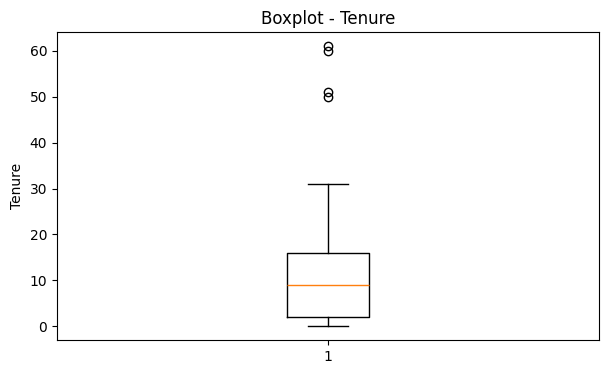

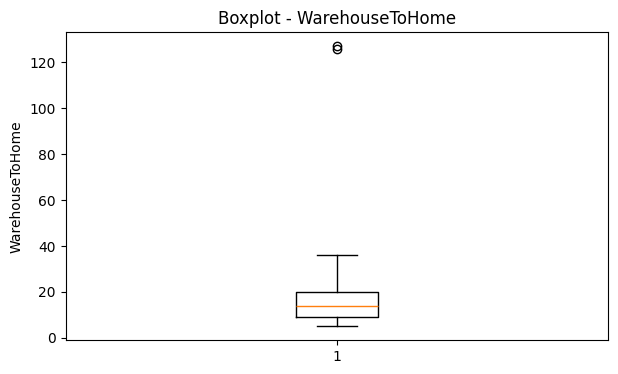

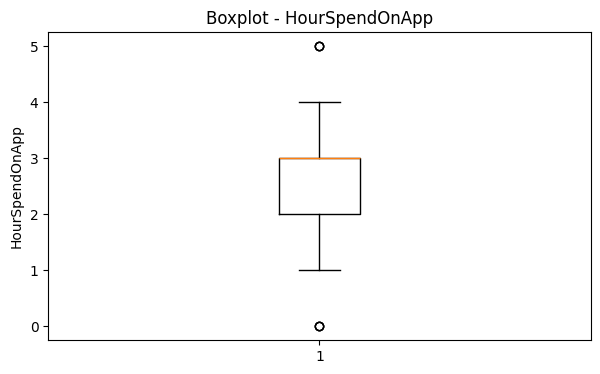

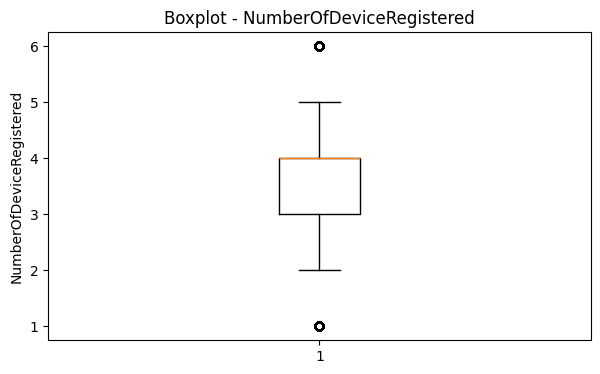

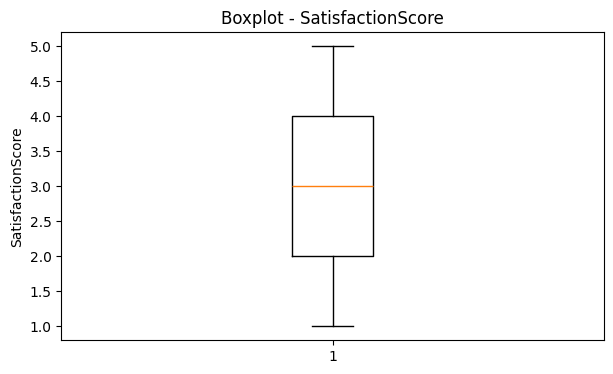

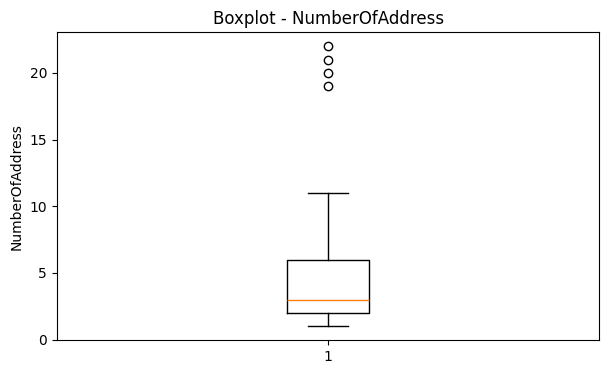

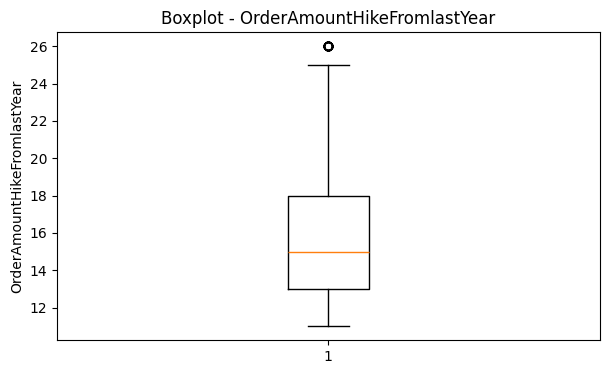

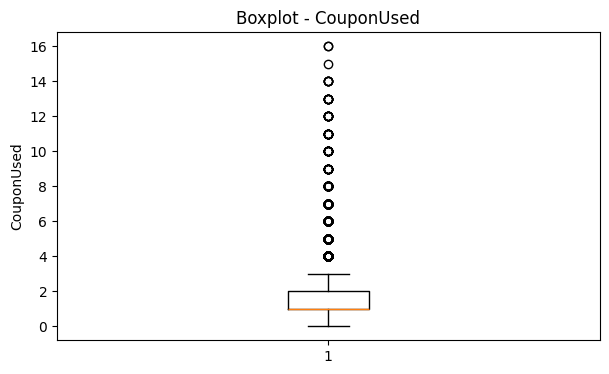

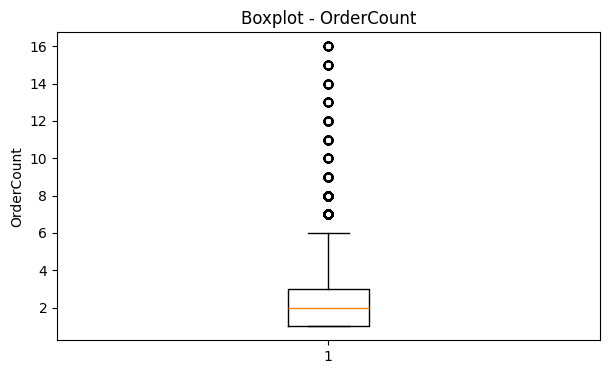

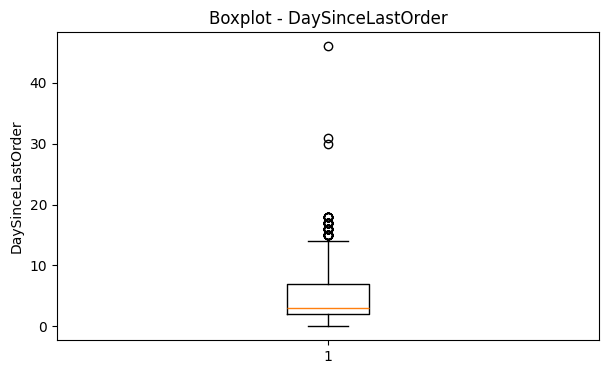

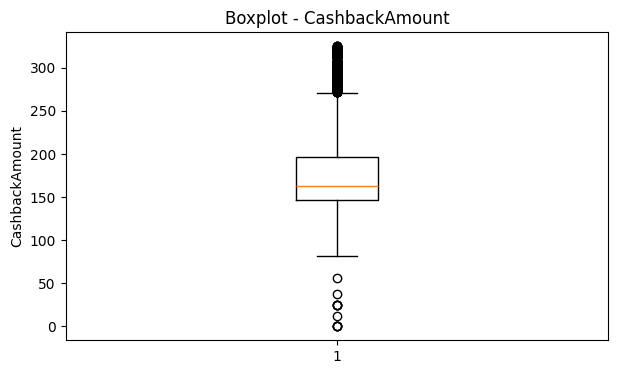

In [ ]:
import matplotlib.pyplot as plt

numeric_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
missing_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder"
]

for col in missing_columns:

    df["is_missing"] = df[col].isna()

    result = df.groupby("is_missing")["Churn"].agg(
        ["count", "mean"]
    )

    print(col)
    print('-------------------------')
    print(result, '\n')

Tenure
-------------------------
            count      mean
is_missing                 
False        5366  0.161573
True          264  0.306818 

WarehouseToHome
-------------------------
            count      mean
is_missing                 
False        5379  0.160625
True          251  0.334661 

HourSpendOnApp
-------------------------
            count      mean
is_missing                 
False        5375  0.165581
True          255  0.227451 

OrderAmountHikeFromlastYear
-------------------------
            count      mean
is_missing                 
False        5365  0.174091
True          265  0.052830 

CouponUsed
-------------------------
            count      mean
is_missing                 
False        5374  0.174916
True          256  0.031250 

OrderCount
-------------------------
            count      mean
is_missing                 
False        5372  0.173120
True          258  0.069767 

DaySinceLastOrder
-------------------------
            count      mean


In [ ]:
df.drop(columns="is_missing", inplace=True)

In [ ]:
from scipy.stats import chi2_contingency

def test_missingness_vs_churn(df, columns):

    results = []

    for col in columns:

        missing_flag = df[col].isna()

        contingency_table = pd.crosstab(
            missing_flag,
            df["Churn"]
        )

        chi2, p_value, dof, expected = chi2_contingency(
            contingency_table
        )

        results.append({
            "Feature": col,
            "Chi2": chi2,
            "p_value": p_value,
            "Significant": p_value < 0.05
        })

    return pd.DataFrame(results).sort_values("p_value")


missing_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder"
]

missingness_tests = test_missingness_vs_churn(
    df,
    missing_columns
)

missingness_tests

,Feature,Chi2,p_value,Significant
1,WarehouseToHome,50.635715,1.112029e-12,True
0,Tenure,36.877562,1.257852e-09,True
4,CouponUsed,34.999034,3.298690e-09,True
3,OrderAmountHikeFromlastYear,25.658302,4.075383e-07,True
5,OrderCount,18.047895,2.154167e-05,True
2,HourSpendOnApp,6.220407,1.262861e-02,True
6,DaySinceLastOrder,0.080266,7.769376e-01,False


The analysis shows that missingness is not equally distributed between churned and retained customers. For several variables, customers with missing values have noticeably different churn rates. **This suggests that missingness itself may contain useful information and should be considered carefully during modelling.**

In [ ]:
df[df["WarehouseToHome"] > 50][
    ["WarehouseToHome", "Churn"]
].sort_values("WarehouseToHome", ascending=False)

,WarehouseToHome,Churn
4124,127.0,0
1309,126.0,0


In [ ]:
print(
    "Values > 50:",
    (df["WarehouseToHome"] > 50).sum()
)

Values > 50: 2


In [ ]:
df.loc[
    df["WarehouseToHome"] > 50,
    :
]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1309,51310,0,25.0,Computer,3,126.0,Debit Card,Male,2.0,3,Mobile,1,Married,3,0,15.0,1.0,1.0,0.0,135
4124,54125,0,26.0,Computer,3,127.0,Debit Card,Male,3.0,4,Mobile Phone,1,Married,4,0,16.0,2.0,2.0,1.0,160


In [ ]:
# Correct identified data-entry errors

df.loc[df["WarehouseToHome"] == 126, "WarehouseToHome"] = 26
df.loc[df["WarehouseToHome"] == 127, "WarehouseToHome"] = 27

print(df["WarehouseToHome"].max())

36.0


Two unusually high values (126 and 127) were identified in WarehouseToHome, while most observations fall within a much smaller range. After checking the corresponding records, these values appeared to be data-entry errors rather than genuine distances. They were corrected to 26 and 27 respectively rather than removing the customers.

# EDA

In [ ]:
binary_features = [
    "Complain"
]

for col in binary_features:

    result = (
        df.groupby(col)["Churn"]
        .agg(["count", "sum", "mean"])
    )

    result["churn_rate_%"] = result["mean"] * 100

    print(f"\n{col}")
    print(result.round(2))


Complain
          count  sum  mean  churn_rate_%
Complain                                
0          4026  440  0.11         10.93
1          1604  508  0.32         31.67


## Numerical Features vs Churn

In [ ]:
numerical_analysis = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

summary = df.groupby("Churn")[numerical_analysis].agg(
    ["mean", "median"]
)

summary

Tenure        WarehouseToHome        HourSpendOnApp         \
            mean median            mean median           mean median   
Churn                                                                  
0      11.502334   10.0       15.353931   13.0       2.925530    3.0   
1       3.379469    1.0       17.134259   15.0       2.961798    3.0   

      NumberOfDeviceRegistered        SatisfactionScore         ...  \
                          mean median              mean median  ...   
Churn                                                           ...   
0                     3.639257    4.0          3.001282    3.0  ...   
1                     3.934599    4.0          3.390295    3.0  ...   

      OrderAmountHikeFromlastYear        CouponUsed        OrderCount         \
                             mean median       mean median       mean median   
Churn                                                                          
0                       15.724893   15.0   1.758232    1.0   3.046601    2.0   
1                       15.627409   14.0   1.717021    1.0   2.823656    2.0   

      DaySinceLastOrder        CashbackAmount         
                   mean median           mean median  
Churn                                                 
0              4.807406    4.0     180.633704  166.0  
1              3.236018    2.0     160.369198  150.0  

[2 rows x 22 columns]


The comparison shows noticeable differences between churned and retained customers for several numerical features. Tenure shows the largest difference, with churned customers having substantially lower average tenure. Differences can also be seen in WarehouseToHome, SatisfactionScore, DaySinceLastOrder and CashbackAmount. These variables will be explored further using visualizations and statistical tests.

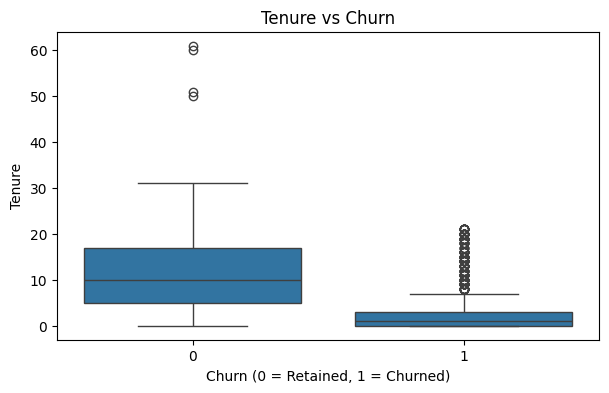

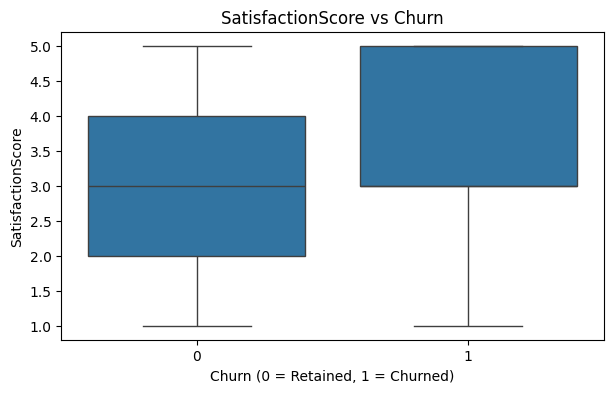

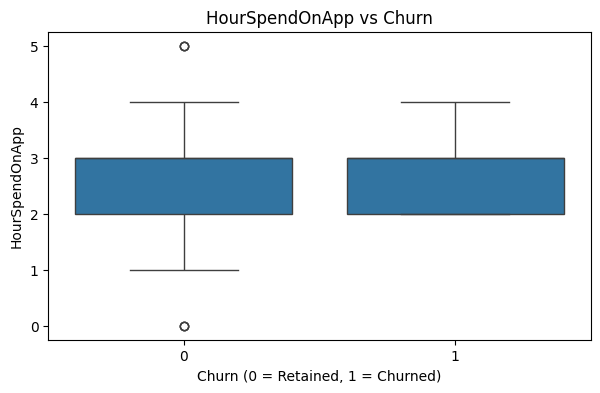

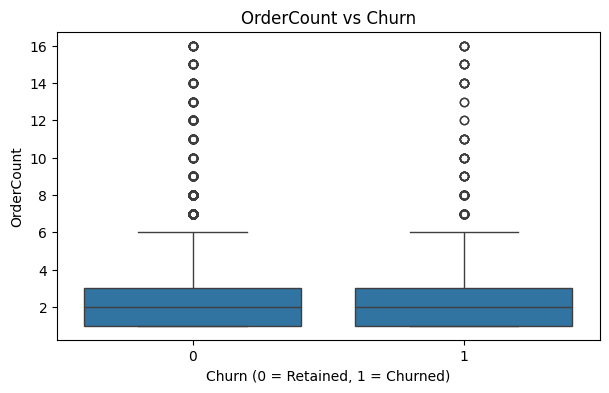

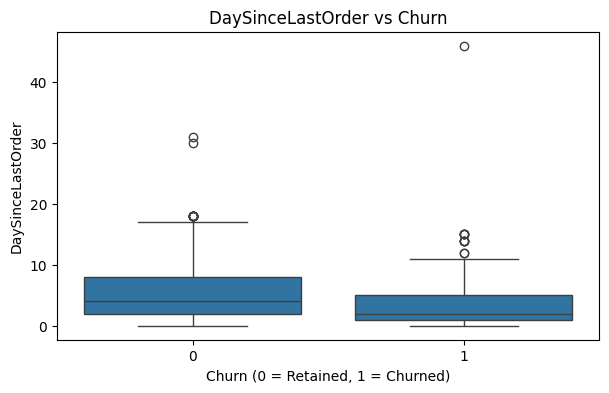

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [
    "Tenure",
    "SatisfactionScore",
    "HourSpendOnApp",
    "OrderCount",
    "DaySinceLastOrder"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=feature)
    plt.title(f"{feature} vs Churn")
    plt.xlabel("Churn (0 = Retained, 1 = Churned)")
    plt.ylabel(feature)
    plt.show()
    print()

* Tenure

Churned customers generally have much lower tenure than retained customers, making tenure a potentially important churn indicator.

* Satisfaction Score

Churned customers show a slightly higher satisfaction score, which is an unexpected pattern that needs further investigation.

* Hour Spend on App

Both groups have very similar app usage, so this feature does not show a strong visual difference.

* Order Count

The order count distributions are quite similar for both groups, with only a small difference in their averages.

* Day Since Last Order

The two groups show some difference in recent order activity, although the pattern is not very strong.

##  Categorical Features vs Churn

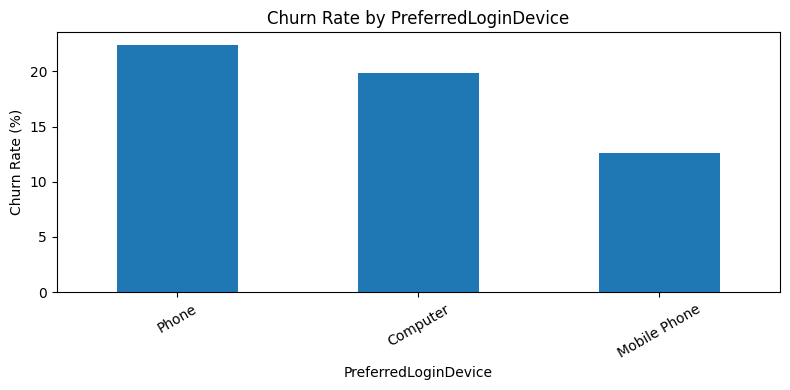

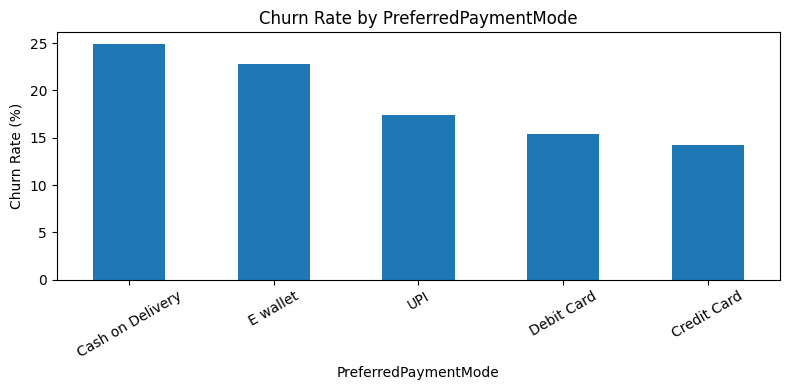

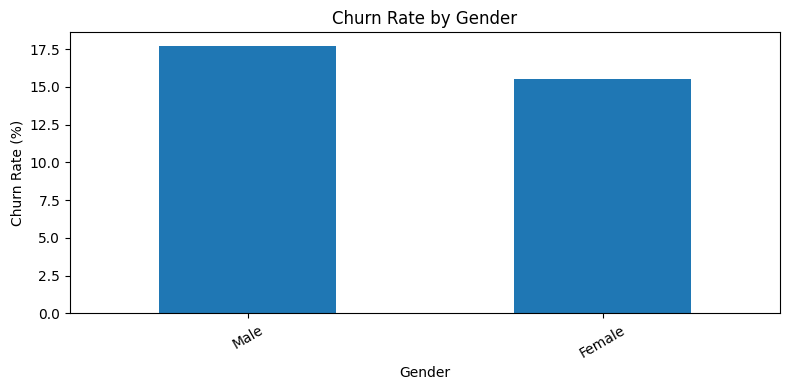

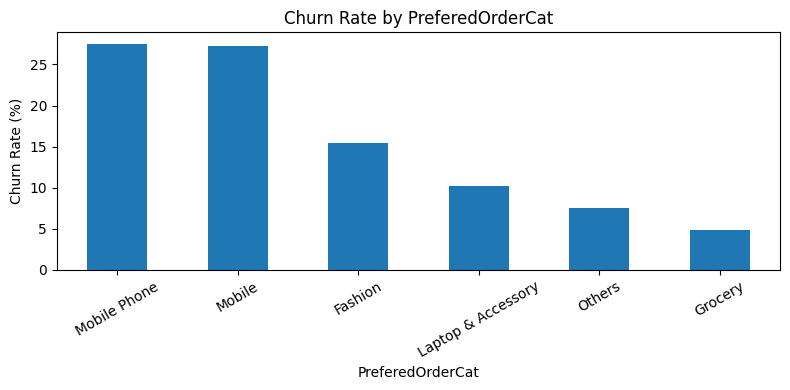

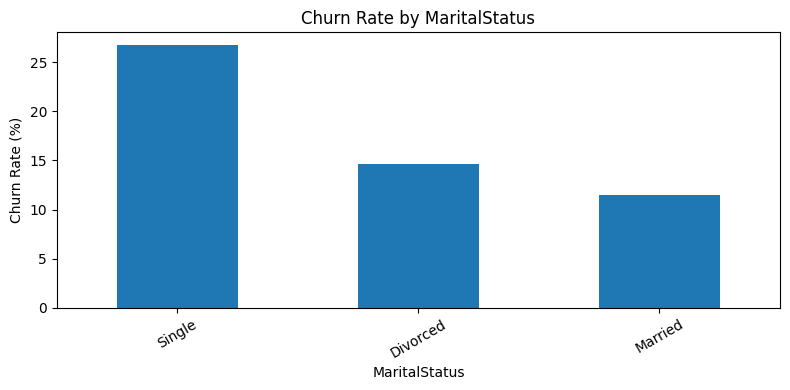

In [ ]:
categorical_features = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

for feature in categorical_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .mean()
        .sort_values(ascending=False) * 100
    )

    plt.figure(figsize=(8, 4))
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {feature}")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

* Preferred Login Device

Churn rate is highest among customers using phones and lowest among mobile-phone users.

* Preferred Payment Mode

Customers using Cash on Delivery and E-wallets show higher churn rates than customers using cards.

* Gender

Male customers have a slightly higher churn rate than female customers.

* Preferred Order Category

Mobile Phone and Mobile customers have the highest churn rates, while Grocery customers have the lowest.

* Marital Status

Single customers show a noticeably higher churn rate than married and divorced customers.

Churn rates vary noticeably across several customer categories, particularly order category, payment mode, login device and marital status. These relationships will be further investigated using statistical testing.

## Behavioural features

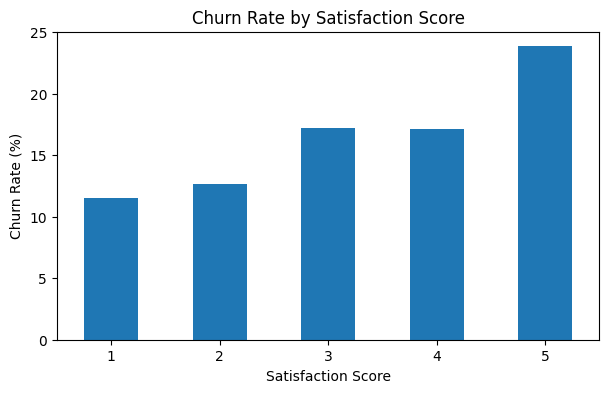

In [ ]:
satisfaction_churn = (
    df.groupby("SatisfactionScore")["Churn"]
    .mean() * 100
)

plt.figure(figsize=(7, 4))
satisfaction_churn.plot(kind="bar")
plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

The churn rate varies across satisfaction levels, indicating a potential relationship between customer satisfaction and churn. This relationship will be formally tested in the hypothesis testing section.

In [ ]:
order_category_churn = (
    df.groupby("PreferedOrderCat")["Churn"]
    .mean()
    .sort_values(ascending=False) * 100
)

order_category_churn.round(2)

,Churn
PreferedOrderCat,
Mobile Phone,27.54
Mobile,27.19
Fashion,15.50
Laptop & Accessory,10.24
Others,7.58
Grocery,4.88


Mobile Phone and Mobile categories have the highest churn rates at 27.54% and 27.19%, while Grocery has the lowest at 4.88%.

# Hypothesis Testing

##  Tenure vs Churn
* H₀ (Null Hypothesis):
The average tenure is the same for churned and retained customers.

* H₁ (Alternative Hypothesis):
The average tenure is different between churned and retained customers.

In [ ]:
from scipy.stats import ttest_ind

retained_tenure = df[df["Churn"] == 0]["Tenure"].dropna()
churned_tenure = df[df["Churn"] == 1]["Tenure"].dropna()

t_stat, p_value = ttest_ind(
    retained_tenure,
    churned_tenure,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", p_value)

T-statistic: 36.157
P-value: 1.4001330621444568e-214


In [ ]:
if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in tenure between churned and retained customers.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that tenure differs between the two groups.")

Result: Reject the null hypothesis.
There is a statistically significant difference in tenure between churned and retained customers.


Low tenure is significantly associated with customer churn

##  Satisfaction Score vs Churn

* H₀:The average satisfaction score is the same for churned and retained customers.

* H₁:The average satisfaction score is different between churned and retained customers.

In [ ]:
retained_satisfaction = df[df["Churn"] == 0]["SatisfactionScore"].dropna()
churned_satisfaction = df[df["Churn"] == 1]["SatisfactionScore"].dropna()

t_stat, p_value = ttest_ind(
    retained_satisfaction,
    churned_satisfaction,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in satisfaction scores between churned and retained customers.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that satisfaction scores differ between the two groups.")

T-statistic: -8.101
P-value: 1.1847878426006565e-15
Result: Reject the null hypothesis.
There is a statistically significant difference in satisfaction scores between churned and retained customers.


## Preferred Order Category vs Churn

**H₀:** Preferred order category and churn are independent.

**H₁:** Preferred order category and churn are associated.

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["PreferedOrderCat"],
    df["Churn"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Preferred order category is significantly associated with churn.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association between order category and churn.")

Chi-square statistic: 288.639
P-value: 2.7708325346337454e-60
Result: Reject the null hypothesis.
Preferred order category is significantly associated with churn.


## Preferred Payment Mode vs Churn

**H₀:** Preferred payment mode and churn are independent.

**H₁:** Preferred payment mode and churn are associated.

In [ ]:
contingency_table = pd.crosstab(
    df["PreferredPaymentMode"],
    df["Churn"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Preferred payment mode is significantly associated with churn.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association between payment mode and churn.")

Chi-square statistic: 51.829
P-value: 1.4978570960706217e-10
Result: Reject the null hypothesis.
Preferred payment mode is significantly associated with churn.


## Conclusion
The statistical tests confirm that tenure, satisfaction score, preferred order category and preferred payment mode have significant relationships with customer churn. These findings will guide the next stage of feature preparation and predictive modelling.

# Feature Engineering & Data Preparation

In [ ]:
# copy
model_df = df.copy()

# Remove CustomerID
model_df = model_df.drop(columns=["CustomerID"])

print("Shape of modelling dataset:", model_df.shape)
model_df.head()

Shape of modelling dataset: (5630, 19)


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,Credit Card,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [ ]:

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (5630, 18)
y shape: (5630,)

Target distribution:
Churn
0    4682
1     948
Name: count, dtype: int64


## Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (4504, 18)
Testing features: (1126, 18)

Training target distribution:
Churn
0    3746
1     758
Name: count, dtype: int64

Testing target distribution:
Churn
0    936
1    190
Name: count, dtype: int64


In [ ]:
# Identify numerical and categorical features

categorical_features = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Numerical features:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Number of categorical features: 5
Number of numerical features: 13


## Preprocessing Pipeline


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# Model Building

## Logistic Regression Model and evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train
logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'CityTier',
                                                   'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'SatisfactionScore',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       936
           1       0.74      0.52      0.61       190

    accuracy                           0.89      1126
   macro avg       0.83      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126

ROC-AUC: 0.8862

Confusion Matrix:
[[902  34]
 [ 91  99]]


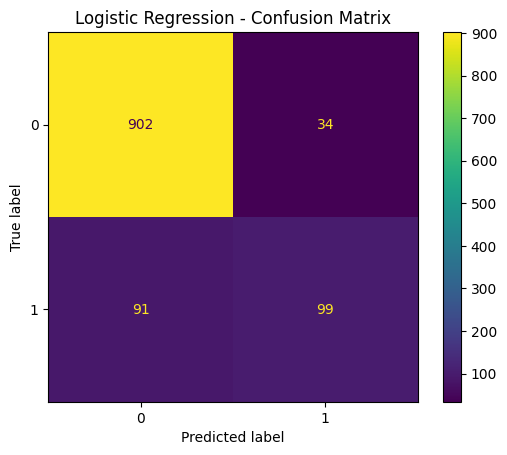

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = logistic_model.predict(X_test)

# Generate probability of churn
y_prob = logistic_model.predict_proba(X_test)[:, 1]


print("Classification Report:\n")
print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

The Logistic Regression model achieved a ROC-AUC of 0.8862, indicating good overall ability to distinguish between churned and retained customers.

For the churn class, the model achieved
* 74% precision but
* only 52% recall, meaning it correctly identifies about **half of the customers who actually churn.**

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'CityTier',
                                                   'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'SatisfactionScore',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       1.00      0.85      0.92       190

    accuracy                           0.98      1126
   macro avg       0.99      0.93      0.95      1126
weighted avg       0.98      0.98      0.97      1126

ROC-AUC: 0.9987

Confusion Matrix:
[[936   0]
 [ 28 162]]


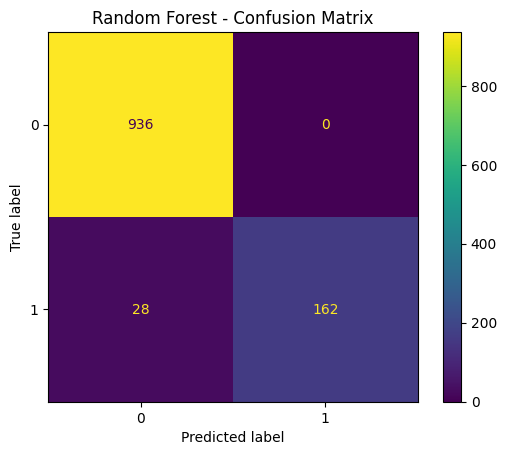

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC:", round(roc_auc_rf, 4))

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)

# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

Recall = 162 / 190 = 85.3%

That's excellent compared with Logistic Regression's 52%.

The Random Forest model substantially outperformed the Logistic Regression baseline.
*  **F1-score of 0.92** for the churn class, indicating a **strong balance between precision and recall**.

## XGBoost

In [ ]:
from xgboost import XGBClassifier

# Create XGBoost pipeline
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.93      0.83      0.88       190

    accuracy                           0.96      1126
   macro avg       0.95      0.91      0.93      1126
weighted avg       0.96      0.96      0.96      1126

ROC-AUC: 0.9915

Confusion Matrix:
[[925  11]
 [ 33 157]]


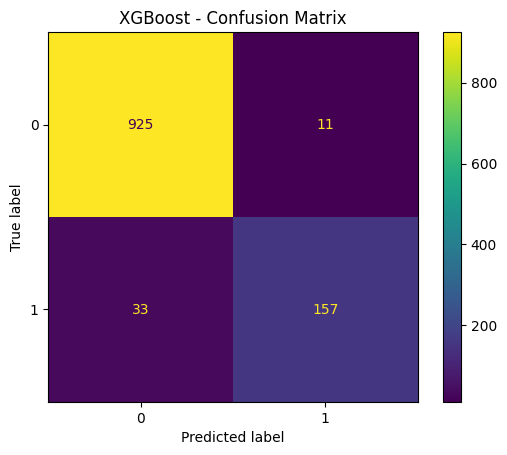

In [ ]:

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC:", round(roc_auc_xgb, 4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix:")
print(cm_xgb)

# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_xgb).plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Churn Precision": [
        0.74,
        1.00,
        0.93
    ],
    "Churn Recall": [
        0.52,
        0.85,
        0.83
    ],
    "Churn F1": [
        0.61,
        0.92,
        0.88
    ],
    "ROC-AUC": [
        0.8862,
        0.9987,
        0.9915
    ]
})

model_comparison

,Model,Churn Precision,Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,0.74,0.52,0.61,0.8862
1,Random Forest,1.00,0.85,0.92,0.9987
2,XGBoost,0.93,0.83,0.88,0.9915


Among the three models,
*  **Random Forest** achieved the best overall performance on the test set. It obtained the highest churn recall (85%), churn F1-score (0.92), and ROC-AUC (0.9987).
* XGBoost also performed strongly, while Logistic Regression provided a useful baseline but had substantially lower churn recall.

Random Forest will therefore be considered for further analysis.

In [ ]:
rf_classifier = random_forest_model.named_steps["classifier"]

feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = rf_classifier.feature_importances_

# Create a dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

# Display top 15 features
print("Top 15 features:")
display(feature_importance_df.head(15))

Top 15 features:


,Feature,Importance
0,num__Tenure,0.241779
12,num__CashbackAmount,0.087302
2,num__WarehouseToHome,0.062976
7,num__Complain,0.062101
11,num__DaySinceLastOrder,0.061094
6,num__NumberOfAddress,0.050532
8,num__OrderAmountHikeFromlastYear,0.049777
5,num__SatisfactionScore,0.046584
4,num__NumberOfDeviceRegistered,0.031294
10,num__OrderCount,0.028177


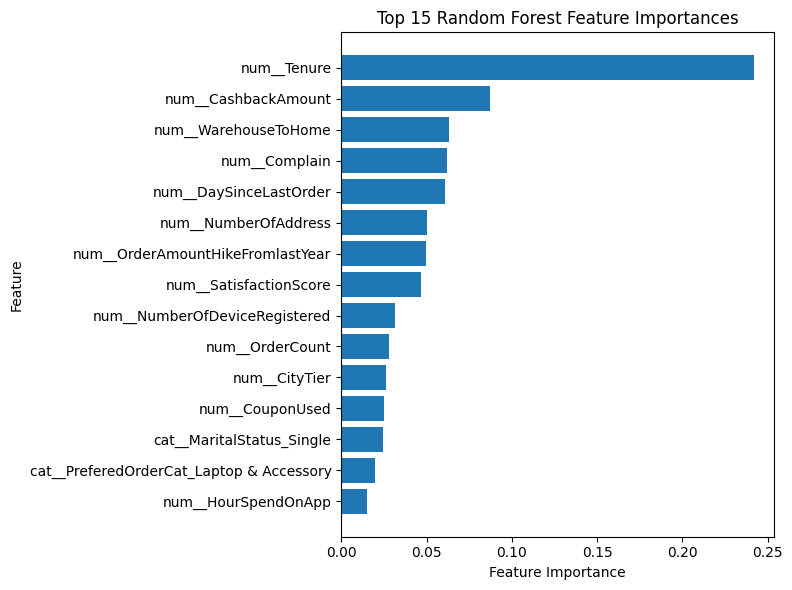

In [ ]:
top_features = feature_importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Predict churn probabilities for training and testing data

y_prob_train_rf = random_forest_model.predict_proba(X_train)[:, 1]
y_prob_test_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
train_auc_rf = roc_auc_score(y_train, y_prob_train_rf)
test_auc_rf = roc_auc_score(y_test, y_prob_test_rf)

print("Random Forest Training ROC-AUC:", round(train_auc_rf, 4))
print("Random Forest Testing ROC-AUC:", round(test_auc_rf, 4))
print("Difference:", round(train_auc_rf - test_auc_rf, 4))

Random Forest Training ROC-AUC: 1.0
Random Forest Testing ROC-AUC: 0.9987
Difference: 0.0013


The small gap between training and testing performance suggests that the model **does not show an obvious sign of severe overfitting** on the hold-out test set.

The model can therefore be considered a strong candidate for further churn analysis.

##  Final Model Selection

Based on the evaluation results,
* Random Forest is selected as the leading model for customer churn prediction.

It achieved the highest churn recall, F1-score and ROC-AUC among the three models tested. Its strong performance indicates that it can effectively distinguish customers who are likely to churn from those who are likely to remain.

# Save model and cleaned data

In [ ]:
# Save cleaned dataset for further analysis
df.to_csv("/content/cleaned_churn_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
import joblib

# Save the complete preprocessing + Random Forest pipeline
joblib.dump(
    random_forest_model,
    "/content/churn_random_forest_pipeline.pkl"
)

print("Model pipeline saved successfully.")

Model pipeline saved successfully.


In [ ]:
import os

print("Model file exists:", os.path.exists("/content/churn_random_forest_pipeline.pkl"))
print("Cleaned data exists:", os.path.exists("/content/cleaned_churn_data.csv"))

Model file exists: True
Cleaned data exists: True
